# 005. Validate BCHH relative infrasound calibration

This notebook imports raw-count MiniSEED extracts for three nearby routine launches and the AMOS-6 fireball. It tests whether the **relative** gain of DD2 and DD3 is stable. It does not replace the empirical 2016 lift-test conversion factors or claim an absolute laboratory calibration.

Place one raw-count MiniSEED file per event in `data/miniseed/2016_launch_calibration/`. The notebook exports compact QC tables and a figure to `data/outputs/005_validate_bchh_relative_calibration/`, making these inputs and outputs suitable for the Zenodo release.


In [1]:
from pathlib import Path
import sys
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy import Stream, UTCDateTime, read
from obspy.clients.filesystem.sds import Client as SDSClient

here = Path.cwd().resolve()
ROOT = next((p for p in [here, *here.parents] if (p / "modules" / "project_config.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Run from the fireball-paper repository or its notebooks directory.")
sys.path.insert(0, str(ROOT / "modules"))
from project_config import MINISEED_DIR, SDS_DIR, notebook_output_dir
NB005_DIR = notebook_output_dir(5, "validate_bchh_relative_calibration")

INPUT_DIR = MINISEED_DIR / "2016_launch_calibration"
OUT = NB005_DIR
OUT.mkdir(parents=True, exist_ok=True)
PRESSURE_IDS = ("1R.BCHH.10.DD1", "1R.BCHH.10.DD2", "1R.BCHH.10.DD3")
ADOPTED_COUNTS_PER_PA = {"DD1": 8.10, "DD2": 0.690, "DD3": 10.0}

EVENTS = pd.DataFrame([
    {"event_id":"jcsat16", "mission":"JCSAT-16", "event_time_utc":"2016-08-14T05:26:00Z", "role":"routine_launch", "file":"jcsat16_bchh_raw.mseed"},
    {"event_id":"afspc6", "mission":"AFSPC-6", "event_time_utc":"2016-08-19T04:52:00Z", "role":"routine_launch", "file":"afspc6_bchh_raw.mseed"},
    {"event_id":"amos6", "mission":"AMOS-6 fireball", "event_time_utc":"2016-09-01T13:07:15.5136Z", "role":"stress_test", "file":"amos6_bchh_raw.mseed"},
    {"event_id":"osirisrex", "mission":"OSIRIS-REx", "event_time_utc":"2016-09-08T23:05:00Z", "role":"routine_launch", "file":"osirisrex_bchh_raw.mseed"},
])
EVENTS


,event_id,mission,event_time_utc,role,file
0,jcsat16,JCSAT-16,2016-08-14T05:26:00Z,routine_launch,jcsat16_bchh_raw.mseed
1,afspc6,AFSPC-6,2016-08-19T04:52:00Z,routine_launch,afspc6_bchh_raw.mseed
2,amos6,AMOS-6 fireball,2016-09-01T13:07:15.5136Z,stress_test,amos6_bchh_raw.mseed
3,osirisrex,OSIRIS-REx,2016-09-08T23:05:00Z,routine_launch,osirisrex_bchh_raw.mseed


## Inputs and processing

All traces are treated as raw digitizer counts. Each trace is linearly detrended, demeaned, cosine tapered, and zero-phase high-pass filtered at 0.1 Hz. The same 50-s post-onset window is used for all pairwise RMS comparisons within an event.

A trace-level timing shift does not materially change RMS ratios; lagged cross-correlation is included only as a coherence diagnostic.


In [2]:
PRE_S, POST_S = 30.0, 240.0
HIGHPASS_HZ, FILTER_CORNERS, TAPER_FRACTION = 0.1, 4, 0.05
NOISE_WINDOW, SEARCH_WINDOW = (-25.0, -5.0), (0.0, 180.0)
ENV_WINDOW_S, ONSET_SNR, CAL_WINDOW_LENGTH_S = 1.0, 5.0, 50.0

def preprocess_counts(st):
    out = Stream()
    for tr in st:
        if tr.id not in PRESSURE_IDS:
            continue
        x = tr.copy()
        x.detrend("linear"); x.detrend("demean")
        x.taper(max_percentage=TAPER_FRACTION, type="cosine")
        x.filter("highpass", freq=HIGHPASS_HZ, corners=FILTER_CORNERS, zerophase=True)
        out.append(x)
    return out

def rolling_rms(x, n):
    return np.sqrt(pd.Series(np.asarray(x, float)**2).rolling(n, center=True, min_periods=max(1,n//3)).mean().to_numpy())

def channel_snr(tr, t0):
    sr = float(tr.stats.sampling_rate)
    t = np.arange(tr.stats.npts) / sr + float(tr.stats.starttime - t0)
    env = rolling_rms(tr.data, max(1, round(ENV_WINDOW_S * sr)))
    noise = np.nanmedian(env[(t >= NOISE_WINDOW[0]) & (t <= NOISE_WINDOW[1])])
    return t, env / noise if np.isfinite(noise) and noise > 0 else np.full_like(env, np.nan)

def shared_arrays(tr_a, tr_b, max_lag_s=0.25):
    sr = float(tr_a.stats.sampling_rate)
    if not np.isclose(sr, float(tr_b.stats.sampling_rate)):
        raise ValueError("Sampling rates differ")
    start, end = max(tr_a.stats.starttime, tr_b.stats.starttime), min(tr_a.stats.endtime, tr_b.stats.endtime)
    a, b = tr_a.copy().trim(start, end).data.astype(float), tr_b.copy().trim(start, end).data.astype(float)
    n = min(len(a), len(b)); a, b = a[:n], b[:n]
    good = np.isfinite(a) & np.isfinite(b); a, b = a[good], b[good]
    a0, b0 = a-a.mean(), b-b.mean()
    nlag = int(round(max_lag_s * sr))
    lags = np.arange(-nlag, nlag+1)
    scores = [np.dot(a0[max(0,l):min(len(a0),len(a0)+l)], b0[max(0,-l):min(len(b0),len(b0)-l)]) for l in lags]
    lag = int(lags[np.argmax(scores)])
    if lag > 0: aa, bb = a[lag:], b[:-lag]
    elif lag < 0: aa, bb = a[:lag], b[-lag:]
    else: aa, bb = a, b
    return aa, bb, lag / sr

def pair_metrics(tr_a, tr_b):
    a, b, lag_s = shared_arrays(tr_a, tr_b)
    rms = lambda x: np.sqrt(np.mean(x*x))
    return dict(rms_ratio=rms(a)/rms(b), lag_s=lag_s,
                lagged_correlation=np.corrcoef(a,b)[0,1], npts=len(a))


In [3]:
def read_raw_event(row):
    """Use the portable extract when present; otherwise make it from local SDS."""
    path = INPUT_DIR / row.file
    if path.is_file():
        return read(str(path))
    if SDS_DIR is None or not Path(SDS_DIR).is_dir():
        raise FileNotFoundError(
            f"Missing {path}. Put the raw-count extract there, or set "
            "[external_paths] sds_dir in local_config.toml to your SDS_KSC archive."
        )
    t0 = UTCDateTime(row.event_time_utc)
    client = SDSClient(str(SDS_DIR))
    st = Stream()
    for channel in ("DD1", "DD2", "DD3"):
        st += client.get_waveforms("1R", "BCHH", "10", channel, t0-PRE_S, t0+POST_S)
    if not st:
        raise FileNotFoundError(f"No BCHH pressure data found in {SDS_DIR} for {row.event_id}.")
    INPUT_DIR.mkdir(parents=True, exist_ok=True)
    st.write(str(path), format="MSEED")
    print(f"Created portable raw-count extract: {path}")
    return st

def read_and_window(row):
    t0 = UTCDateTime(row.event_time_utc)
    st = preprocess_counts(read_raw_event(row).trim(t0-PRE_S, t0+POST_S))
    by_id = {tr.id: tr for tr in st}
    if any(seed not in by_id for seed in PRESSURE_IDS[1:]):
        raise ValueError(f"{row.event_id} is missing DD2 or DD3")
    onsets=[]
    for seed in PRESSURE_IDS[1:]:
        t, snr = channel_snr(by_id[seed], t0)
        hits = np.flatnonzero((t >= SEARCH_WINDOW[0]) & (t <= SEARCH_WINDOW[1]) & (snr >= ONSET_SNR))
        if not len(hits):
            raise ValueError(f"No DD2/DD3 SNR>{ONSET_SNR} onset for {row.event_id}; inspect waveform and set a reviewed override.")
        onsets.append(float(t[hits[0]]))
    start = max(onsets); stop = min(start + CAL_WINDOW_LENGTH_S, SEARCH_WINDOW[1])
    traces = {seed: by_id[seed].copy().trim(t0+start, t0+stop) for seed in by_id}
    return st, traces, dict(event_id=row.event_id, mission=row.mission, role=row.role, signal_start_s=start, signal_end_s=stop)

streams, windows, rows = {}, {}, []
for row in EVENTS.itertuples(index=False):
    st, traces, window = read_and_window(row)
    streams[row.event_id], windows[row.event_id] = st, traces
    rows.append(window)
window_qc = pd.DataFrame(rows)
window_qc


Created portable raw-count extract: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/miniseed/2016_launch_calibration/jcsat16_bchh_raw.mseed
Created portable raw-count extract: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/miniseed/2016_launch_calibration/afspc6_bchh_raw.mseed
Created portable raw-count extract: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/miniseed/2016_launch_calibration/amos6_bchh_raw.mseed
Created portable raw-count extract: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/miniseed/2016_launch_calibration/osirisrex_bchh_raw.mseed


,event_id,mission,role,signal_start_s,signal_end_s
0,jcsat16,JCSAT-16,routine_launch,2.5480,52.5480
1,afspc6,AFSPC-6,routine_launch,24.7200,74.7200
2,amos6,AMOS-6 fireball,stress_test,0.8584,50.8584
3,osirisrex,OSIRIS-REx,routine_launch,5.7400,55.7400


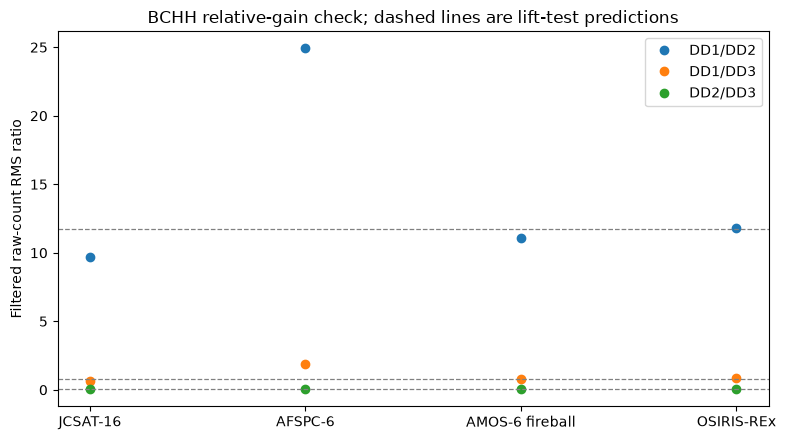

In [4]:
metrics=[]
for row in EVENTS.itertuples(index=False):
    tr = windows[row.event_id]
    for left, right in combinations(PRESSURE_IDS, 2):
        if left not in tr or right not in tr:
            continue
        result = pair_metrics(tr[left], tr[right])
        metrics.append({"event_id":row.event_id, "mission":row.mission, "role":row.role,
                        "pair":f"{left.split('.')[-1]}/{right.split('.')[-1]}", **result})
relative = pd.DataFrame(metrics)
relative["expected_lift_ratio"] = relative.pair.map({
    "DD1/DD2": ADOPTED_COUNTS_PER_PA["DD1"]/ADOPTED_COUNTS_PER_PA["DD2"],
    "DD1/DD3": ADOPTED_COUNTS_PER_PA["DD1"]/ADOPTED_COUNTS_PER_PA["DD3"],
    "DD2/DD3": ADOPTED_COUNTS_PER_PA["DD2"]/ADOPTED_COUNTS_PER_PA["DD3"],
})
relative["interpretation"] = np.where(relative.pair.eq("DD2/DD3"), "primary relative-gain comparison", "secondary QC; DD1 is noisier")
relative

fig, ax = plt.subplots(figsize=(8,4.5))
for pair, group in relative.groupby("pair"):
    ax.plot(group.mission, group.rms_ratio, "o", label=pair)
for pair, expected in relative.groupby("pair").expected_lift_ratio.first().items():
    ax.axhline(expected, lw=.9, ls="--", color="0.5")
ax.set_ylabel("Filtered raw-count RMS ratio")
ax.set_title("BCHH relative-gain check; dashed lines are lift-test predictions")
ax.legend(); fig.tight_layout()
fig.savefig(OUT / "relative_gain_filtered_counts.pdf", bbox_inches="tight")
plt.show()


## Interpretation

The primary result is the DD2/DD3 comparison: ordinary launches should cluster near the lift-test prediction of 0.0690. The AMOS-6 result is an extreme-amplitude stress test and is not used to set the calibration. DD1 is useful secondary evidence but should not drive the conclusion, especially for AFSPC-6 where it is noisy.

The check supports relative stability; it does not establish an absolute calibration, serial-number assignments, DD2's nominal configuration, or linearity at the largest fireball pressures.


In [5]:
window_qc.to_csv(OUT / "signal_window_qc.csv", index=False)
relative.to_csv(OUT / "relative_gain_filtered_counts.csv", index=False)
pd.DataFrame([{
    "adopted_dd1_counts_per_pa": 8.10,
    "adopted_dd2_counts_per_pa": 0.690,
    "adopted_dd3_counts_per_pa": 10.0,
    "nominal_likely_1inch_counts_per_pa": 9.2,
    "dd3_nominal_pressure_change_percent": (10.0/9.2-1)*100,
    "dd2_dd3_lift_prediction": 0.690/10.0,
}]).to_csv(OUT / "calibration_reference_values.csv", index=False)
EVENTS.to_csv(OUT / "event_provenance.csv", index=False)
print(f"Wrote calibration QC products to {OUT}")


Wrote calibration QC products to /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/005_validate_bchh_relative_calibration
